# Series resummation on the infinite 2d square lattice

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
import h5py
from robustpade import pade_approx, pade_approx_batch 

## Free energy density as function of chemical potential: $\beta t= 1.0$, $U/t=6$

$-k_BT \ln Z$ as a function of $\mu$. 

In [ ]:
U=6.0
beta=1.0

In [2]:
def Z_atomic(U:float, beta:float, mu:float):

    return 1+2*np.exp(beta*mu)+np.exp(beta*(2*mu - U))


def a_0(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)
    return -1/beta*np.log(Zat) # factor 2 for spin and


def a_2(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)

    fact = np.exp(beta*mu)/Zat**2
    A = beta**2/2*(1+np.exp(-beta*(U-2*mu)))
    B = 2*beta/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)
    return -2/beta*fact*(A+B)*4 #factor 2 for spin and 2 for sites!


In [ ]:
#load order4
with h5py.File('/Users/louissharma/Desktop/results_sc/results/full_lattice_Omega_order_4_scan_mu_U=6.0_beta=1.0_alpha=0.3_old.h5', 'r') as f:
    mus = f['mu_list'][:]
    means_4 = f['mean_list'][:]
    errors_4 = f['error_list'][:]

#loard order 6
with h5py.File('/Users/louissharma/Desktop/results_sc/results/full_lattice_Omega_order_6_scan_mu_U=6.0_beta=1.0_alpha=0.3_old.h5', 'r') as f:
    mus_6 = f['mu_list'][:]
    means_6 = f['mean_list'][:]
    errors_6 = f['error_list'][:]

In [ ]:
a4 = means_4
a6 = means_6
rm_index = np.where(mus_6 == 2.0)[0][0]
mus_6 = np.delete(mus_6, rm_index)
a6 = np.delete(a6, rm_index)
errors_6 = np.delete(errors_6, rm_index)

Plot coeffs and error bars

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(mus, a4, yerr=errors_4, fmt='o', label='order 4')
#ax.errorbar(mus_6, a6, yerr=errors_6, fmt='o', label='order 6')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel('$a_4$')
ax.legend()

ax2 = ax.twinx()
ax2.errorbar(mus, a6, yerr=errors_6, fmt='o', label='order 6', color='orange', markersize=5)
ax2.set_ylabel('$a_6$')
ax2.legend(loc='upper right')


In [ ]:
errors_6/a6*100

In [ ]:
fig, ax = plt.subplots()

ax.scatter(mus, errors_4/np.abs(a4), label='order 4')

ax.scatter(mus_6, errors_6/np.abs(a6), label='order 6')

In [ ]:
t = 0.9
g = t**2
coeffs_sq = np.array([a_0(U, beta, mus), a_2(U, beta, mus),a4, a6]) #treat as a function of t^2

orders = {(2,1): [], (1,2): []}
for order in orders.keys():
    pade_sum = pade_approx_batch(coeffs_sq, order, 0.0)(t**2).real
    orders[order].append(pade_sum)

naive_sum_6 = lambda g: a_0(U,beta, mus) + a_2(U, beta, mus)*g + a4*g**2 + a6*g**3

In [ ]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

fig.suptitle(rf'Strong coupling infinite lattice $U/t={ U/t:.2f}$, $\beta t={beta*t}$ order 6')
for order in orders.keys():
    ax1.scatter(mus, orders[order][0], label=f'Pade {order}', s=5)

ax1.scatter(mus, naive_sum_6(1.0), label='order 6 sum', s=5, c='k')

ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel('Free energy density')
ax1.legend()

for order in orders.keys():
    ax2.scatter(mus, -np.gradient(orders[order][0], mus), label=f'Pade {order}', s=5)

ax2.scatter(mus, -np.gradient(naive_sum_6(g), mus), label='order 6 sum', s=5, c='k')
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel('Density')

ax2.plot(mus, -np.gradient(a_0(U, beta, mus), mus), label='atomic limit', c='r', linestyle='dashed')
ax2.legend()

In [ ]:
t = 0.75
g = t**2
partial_sum_6 = lambda g: a_0(U,beta, mus) + a_2(U, beta, mus)*g + a4*g**2 + a6*g**3
partial_sum_4 = lambda g: a_0(U,beta, mus) + a_2(U, beta, mus)*g + a4*g**2

In [ ]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
fig.suptitle(rf'Strong coupling infinite lattice $U/t={ U/t:.2f}$, $\beta t={beta*t}$ order 6')
ax1.scatter(mus/t, partial_sum_6(g), label='partial sum 6', s=5)
ax1.scatter(mus/t, partial_sum_4(g), label='partial sum 4', s=5)
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel('Free energy density')
ax1.legend()

ax2.scatter(mus/t, -np.gradient(partial_sum_6(g), mus), label='partial sum 6', s=5)
ax2.scatter(mus/t, -np.gradient(partial_sum_4(g), mus), label='partial sum 4', s=5)
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel('Density')
ax2.legend()

## $U = 8.0$ $\beta=0.75$ mu scan

In [39]:
U = 8.0
beta = 0.75

In [40]:
#load order4
with h5py.File('/Users/louissharma/Desktop/results_sc/results/full_lattice_Omega_order_4_scan_mu_U=8.0_beta=0.75_alpha=0.3.h5', 'r') as f:
    mus = f['mu_list'][:]
    means_4 = f['mean_list'][:]
    errors_4 = f['error_list'][:]

#load order 6
with h5py.File('/Users/louissharma/Desktop/results_sc/results/full_lattice_Omega_order_6_scan_mu_U=8.0_beta=0.75_alpha=0.3.h5', 'r') as f:
    mus_62 = f['mu_list'][:]
    means_6 = f['mean_list'][:]
    errors_6 = f['error_list'][:]

In [41]:
a4 = means_4
a6 = means_6

In [42]:
t = 1.0
g = t**2
#coeffs_sq = np.array([a_0(U, beta, mus), a_2(U, beta, mus),a4, a6]) #treat as a function of t^2

# orders = {(2,1): [], (1,2): []}
# for order in orders.keys():
#     pade_sum = pade_approx_batch(coeffs_sq, order, 0.0)(t**2).real
#     orders[order].append(pade_sum)

naive_sum_4 = lambda g: a_0(U,beta, mus) + a_2(U, beta, mus)*g + a4*g**2
naive_sum_6 = lambda g: a_0(U,beta, mus) + a_2(U, beta, mus)*g + a4*g**2 + a6*g**3

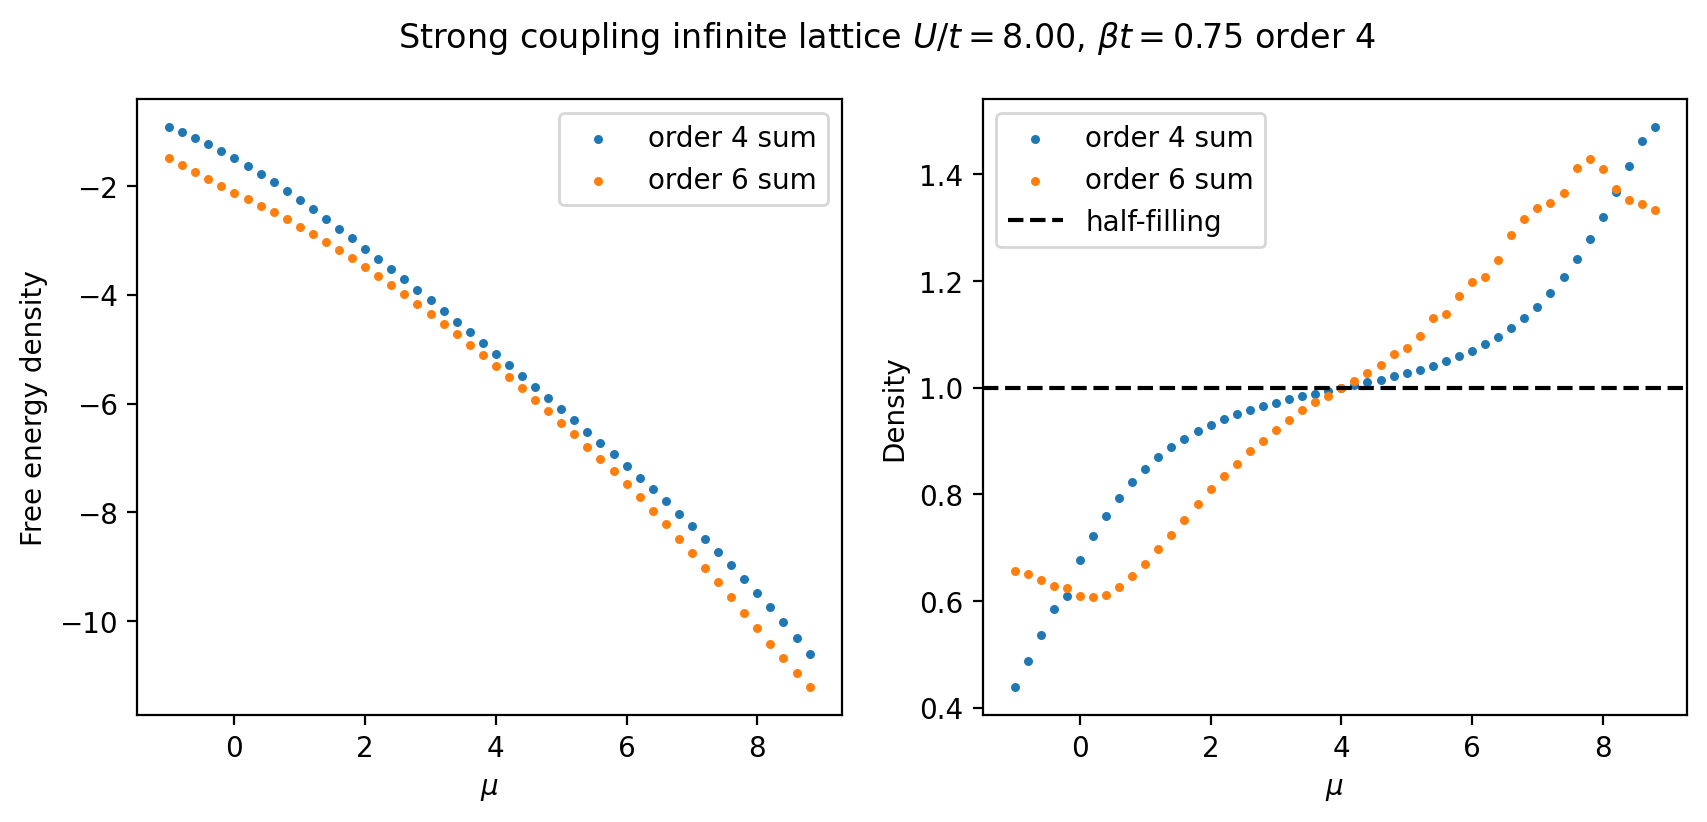

In [43]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
fig.suptitle(rf'Strong coupling infinite lattice $U/t={ U/t:.2f}$, $\beta t={beta*t}$ order 4')
ax1.scatter(mus, naive_sum_4(g), label='order 4 sum', s=5)
ax1.scatter(mus, naive_sum_6(g), label='order 6 sum', s=5)
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel('Free energy density')

ax1.legend()

# for order in orders.keys():
#     ax2.scatter(mus, -np.gradient(orders[order][0], mus), label=f'Pade {order}', s=5)
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel('Density')
#ax2.scatter(mus, -np.gradient(a_0(U, beta, mus), mus), label='atomic limit', c='r', s=5, marker='x')
ax2.scatter(mus, -np.gradient(naive_sum_4(g), mus), label='order 4 sum', s=5)
ax2.scatter(mus, -np.gradient(naive_sum_6(g), mus), label='order 6 sum', s=5)
# ax2.set_xlim(-0.1,4.1)
# ax2.set_ylim(0.65,1.05)
ax2.axhline(1.0, color='r', linestyle='dashed', label='half-filling', c='k')
ax2.legend()

In [47]:
data = np.array([mus, -np.gradient(naive_sum_4(g), mus), -np.gradient(naive_sum_6(g), mus), -np.gradient(a_0(U, beta, mus))])

np.save('./sc_expansion_FE_density_and_mu_U=8.0_beta=0.75_order4_6.npy', data)

In [45]:
data[0]

array([-0.2, -0.4, -0.6, -0.8, -1. ,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,
        1.2,  1.4,  1.6,  1.8,  2. ,  2.2,  2.4,  2.6,  2.8,  3. ,  3.2,
        3.4,  3.6,  3.8,  4. ,  4.2,  4.4,  4.6,  4.8,  5. ,  5.2,  5.4,
        5.6,  5.8,  6. ,  6.2,  6.4,  6.6,  6.8,  7. ,  7.2,  7.4,  7.6,
        7.8,  8. ,  8.2,  8.4,  8.6,  8.8])

In [ ]:
plt.scatter(mus, a4, label='old a4')
plt.scatter(mus, means_42, label='new a4')

plt.legend()

In [ ]:
plt.scatter(mus, a6, label='old a6')
#plt.scatter(mus, means_62, label='new a6')
plt.scatter(mus, a6/means_62)